In [1]:
from tqdm.notebook import tqdm
import numpy as np
import torch
from matplotlib import animation, pyplot as plt

from imagegen.setup import find_root, load_config
import imagegen.unet as unet
import imagegen.train as train
import imagegen.data as data
import imagegen.eval as ieval

In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
CFG_FNAME = find_root() / "config/ddpm_config.yaml"


In [8]:
CFG_FNAME

PosixPath('/Users/davidschneider/code/mrcartoonology/imagegen/config/ddpm_config.yaml')

In [9]:
def load_model(cfg: dict, saved_model: str):
    mdl = unet.UNet()
    state_dict = torch.load(saved_model, map_location=cfg["device"])
    mdl.load_state_dict(state_dict["model_state_dict"])
    mdl.eval()
    return mdl

In [11]:
def setup(epoch=600, device='cpu'):
    saved_model = find_root() / f"saved_models/20250612-2155/model_epoch{epoch:05d}.pt"
    cfg = load_config(CFG_FNAME)
    cfg["device"] = device

    val_ds = data.get_cached_image_dataset(
        split="val",
        verbose=True,
        root_dir=cfg["data"]["resized_dir"],
    )
    val_dl = data.get_dataloader(
        split="val",
        verbose=cfg["verbose"],
        batch_size=cfg["data"]["batch_size"],
        ds=val_ds,
    )

    mdl = load_model(cfg=cfg, saved_model=saved_model)

    return cfg, val_dl, mdl

cfg, val_dl, mdl = setup()


------ CACHING DATASET val -------


Caching images: 100%|███████████████████████████████████████| 10000/10000 [00:01<00:00, 5620.40it/s]

 -- Creating DataLoader val --


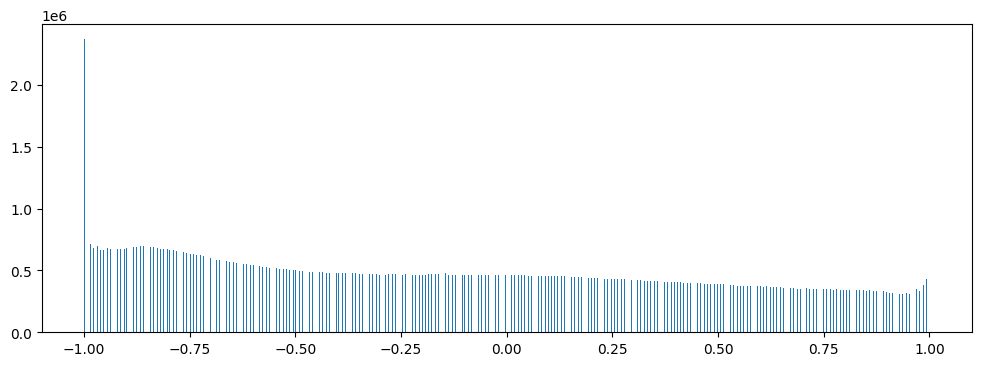

In [13]:
def data_hist(dl):
    arr = np.concatenate([x0.detach().numpy().flatten() for x0 in dl])
    plt.figure(figsize=(12,4))
    plt.hist(arr, bins=1000);

data_hist(val_dl)

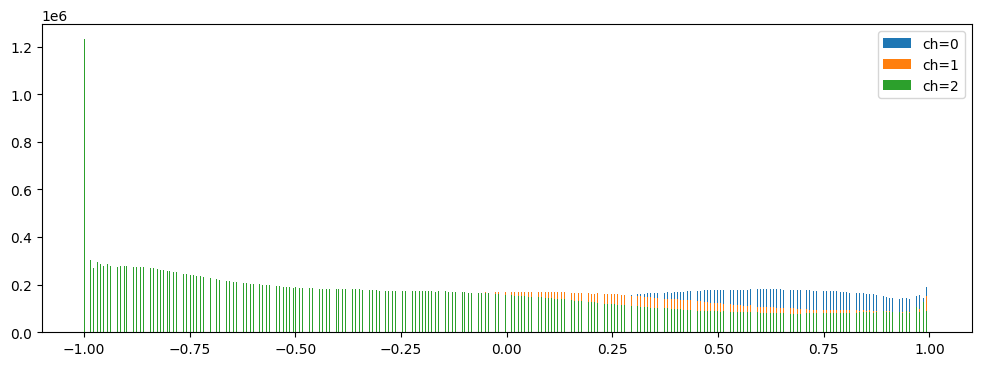

In [15]:
def data_ch_hist(dl):
    plt.figure(figsize=(12,4))
    for ch in range(3):
        arr = np.concatenate([x0[:, ch, :, :].detach().numpy().flatten() for x0 in dl])
        plt.hist(arr, bins=1000, label=f'ch={ch}');
    plt.legend();

data_ch_hist(val_dl)